**Solubilidad del Alcafor en sCO2**
* E.O.S = PR
* Reglas de Mezclado: Van der Waals
* Parametros de interaccion binaria lij y kij -> Pero tomaremos ya los encontrados por el articulo, dado que nos faltan propiedades intensivas para poder hacer el ajuste nosotras mismas. 
* OBJ: Identificar cuando el sistema esta en equilibrio o no. 
* Datos experimentales obtenidos de:
    * Carvalho, R. N., Corazza, M. L., Cardozo-Filho, L., & Meireles, M. A. A. (2006).
          Phase Equilibrium for (Camphor + CO2), (Camphor + Propane), and (Camphor + CO2 +
          Propane). Journal of Chemical & Engineering Data, 51(3), 997–1000.
          https://nebulosa.icesi.edu.co:2144/10.1021/je0505063
    * Cálculo del flash Isotermico (T, P) — documentación de PyTher - 0. (n.d.). Retrieved from https://pyther.readthedocs.io/es/latest/flash.html

**Algoritmo**
1. Definir funcion de Peng Robinson para nuestra mezcla de interes, con parametros de interaccion binaria del articulo. -> Funcion o incluso clase  
2. Determinar los puntos de equilibrio
    * Iterar sobre Temperaturas (rango nuestro) y Presiones (rango nuestro). Especificar #moles en el sistema (sistema global composicion (nos vamos a basar en algun articulo))
    * Calcular el coeficiente de distribución Ki a partir de la relación de Wilson -> Adivinanza inicial -> Funcion
    * Calcular el valor de Beta mínimo 
    * Calcular el valor de Beta máximo
    * Calcular el promedio de beta, usando Beta minimo y Beta máximo
    * Si el promedio da por debajo de 0 o por encima de 1, a esas condiciones no se encuentra en equilibrio.
    * Resolver la ecuación de Rachford-Rice, para calcular Beta con una tolerancia de 1e-6
    * Calcular las fracciones molares del líquido xi y del vapor yi
    * Calcular los coeficientes de fugacidad para las fracciones molares del líquido xi y del vapor yi (funcion de sofi)
    * Calcular el coeficiente de distribución Ki a partir de los coeficientes de fugacidad del componente i en la mezcla de la fase vapor y líquid
    * Verificar la convergencia del sistema con una tolerancia de 1e-6 para deltaKi

In [118]:
#Imports
import numpy as np
import plotly.graph_objects as go
import chemicals
import matplotlib.pyplot as plt
from typing import Literal 
from scipy.optimize import brentq

**Clase**

In [138]:
class CamphorCO2_VLE:
    def __init__(self, z, k12, l12):
        self.R = 8.314462618e-6  # MPa m3 / mol K
        self.z = np.array(z)     # Composición global [z_camfor, z_CO2]
        self.k12 = k12
        self.l12 = l12
        
        # Propiedades puras (Alcanfor = 0, CO2 = 1)
        cas_camphor = chemicals.search_chemical('camphor').CASs
        cas_co2 = chemicals.search_chemical('carbon dioxide').CASs
        
        self.Tc = np.array([chemicals.Tc(cas_camphor), chemicals.Tc(cas_co2)]) # K
        self.Pc = np.array([chemicals.Pc(cas_camphor)/1e6, chemicals.Pc(cas_co2)/1e6]) # MPa
        self.omega = np.array([chemicals.omega(cas_camphor), chemicals.omega(cas_co2)])

    def wilson_K(self, T, P):
        lnKi = np.log(self.Pc / P) + 5.373 * (1 + self.omega) * (1 - self.Tc / T)
        return np.exp(lnKi)

    def calc_eos_cst_pure(self, T):
        b = 0.07780 * (self.R * self.Tc / self.Pc)
        kappa = 0.37464 + 1.54226 * self.omega - 0.2699 * self.omega**2
        alpha = (1 + kappa * (1 - np.sqrt(T / self.Tc)))**2
        a = 0.45724 * ((self.R * self.Tc)**2 / self.Pc) * alpha
        return a, b

    def calc_eos_cst_mix(self, y, a, b):
        a_matrix = np.array([
            [a[0], np.sqrt(a[0]*a[1])*(1-self.k12)],
            [np.sqrt(a[0]*a[1])*(1-self.k12), a[1]]
        ])
        bmix = b[0]*y[0]**2 + 2*y[0]*y[1]*(((b[0]+b[1])/2)*(1-self.l12)) + b[1]*y[1]**2
        amix = a_matrix[0,0]*y[0]**2 + a_matrix[1,1]*y[1]**2 + 2*a_matrix[0,1]*y[0]*y[1]
        return amix, bmix, a_matrix

    def calc_fugacity_coeff(self, T, P, fractions, a, b, phase_type='vapor'):
        amix, bmix, a_matrix = self.calc_eos_cst_mix(fractions, a, b)
        A = amix * P / (self.R**2 * T**2)
        B = bmix * P / (self.R * T)

        coeff = [1.0, -(1.0 - B), A - 3.0 * B**2 - 2.0 * B, -(A * B - B**2 - B**3)]
        roots = np.roots(coeff)
        roots_real = roots[np.isclose(roots.imag, 0.0, atol=1e-9)].real
        
        valid_roots = [r for r in roots_real if r > B]
        if not valid_roots:
            return None
            
        Z = min(valid_roots) if phase_type == 'liquid' else max(valid_roots)
        sqrt2 = np.sqrt(2.0)
        arg_log = (Z + (1.0 + sqrt2) * B) / (Z + (1.0 - sqrt2) * B)
        suma_aj = np.dot(a_matrix, fractions)
        
        term1 = (b / bmix) * (Z - 1.0)
        term2 = -np.log(Z - B)
        term3 = -A / (2.0 * sqrt2 * B)
        term4 = (2.0 * suma_aj / amix) - (b / bmix)
        term5 = np.log(arg_log)

        ln_phi = term1 + term2 + term3 * term4 * term5
        return np.exp(ln_phi)

    def errorRR(self, beta, K):
        return self.z[0] * (K[0] - 1) / (1 + beta * (K[0] - 1)) + self.z[1] * (K[1] - 1) / (1 + beta * (K[1] - 1))

    def solve_flash(self, T, P, max_iter=80, tol=1e-5): #flash ideal
        K = self.wilson_K(T, P)
        a, b = self.calc_eos_cst_pure(T)
        
        for _ in range(max_iter):
            try:
                beta = brentq(self.errorRR, 0.0, 1.0, args=(K))
            except ValueError:
                return None, None 

            x = self.z / (1 + beta * (K - 1))
            y = K * x
            x /= sum(x)
            y /= sum(y)

            phiL = self.calc_fugacity_coeff(T, P, x, a, b, 'liquid')
            phiV = self.calc_fugacity_coeff(T, P, y, a, b, 'vapor')
            
            if phiL is None or phiV is None:
                return None, None
                
            K_new = phiL / phiV
            if np.sum(np.abs(K_new - K)) < tol:
                return x, y
            K = K_new

        return None, None


**Grafica T-x,y**

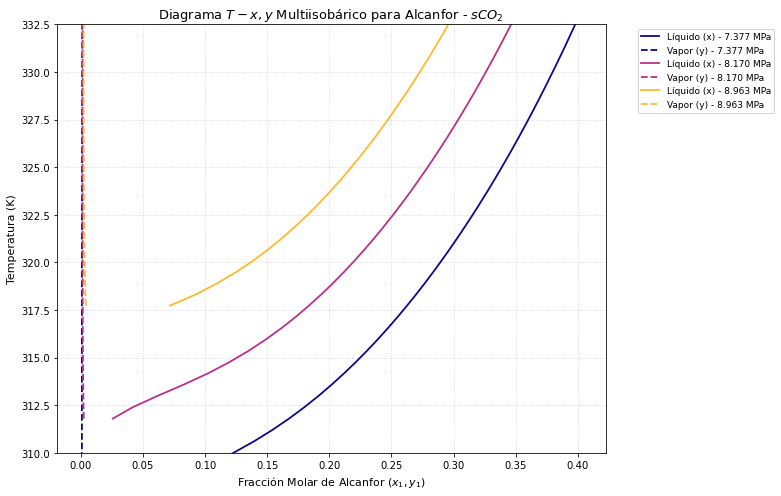

In [140]:
# --- Parámetros del Sistema ---
z_feed = [1.92e-2, 1 - 1.92e-2] # [Alcanfor, CO2]
k12, l12 = 5.4695e-2, -0.6598e-2 #Articulo
temperatures = np.linspace(298.15, 333.15, 60)

vle_model = CamphorCO2_VLE(z_feed, k12, l12)

P_c_CO2 = vle_model.Pc[1]
P_max = 8.963184  
isobaras = np.linspace(P_c_CO2, P_max, 3)

plt.figure(figsize=(11, 7))

colors = plt.cm.plasma(np.linspace(0, 0.85, len(isobaras)))
for P, color in zip(isobaras, colors):
    x_list, y_list, T_list = [], [], []
    
    for T in temperatures:
        x, y = vle_model.solve_flash(T, P)
        if x is not None and y is not None:
            T_list.append(T)
            x_list.append(x[0]) # Fracción molar de Alcanfor en líquido
            y_list.append(y[0]) # Fracción molar de Alcanfor en vapor
            
    if T_list:
        plt.plot(x_list, T_list, linestyle='-', color=color, linewidth=1.8,
                 label=f'Líquido (x) - {P:.3f} MPa')
        plt.plot(y_list, T_list, linestyle='--', color=color, linewidth=1.8,
                 label=f'Vapor (y) - {P:.3f} MPa')

plt.title('Diagrama $T-x,y$ Multiisobárico para Alcanfor - $sCO_2$', fontsize=13)
plt.xlabel('Fracción Molar de Alcanfor ($x_1, y_1$)', fontsize=11)
plt.ylabel('Temperatura (K)', fontsize=11)
plt.ylim(310, 332.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**Grafica de Solubilidad**

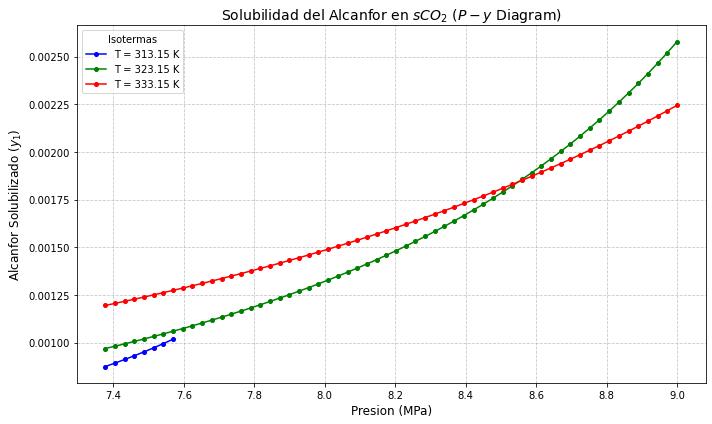

In [121]:
z_feed = [0.15, 0.85] 
k12, l12 = 5.4695e-2, -0.6598e-2

vle_model = CamphorCO2_VLE(z_feed, k12, l12)

isotherms = [313.15, 323.15, 333.15] # K
pressures = np.linspace(P_c_CO2, 9, 60) # MPa 

plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'red']

for T, color in zip(isotherms, colors):
    y_camphor_list = []
    P_plot = []
    
    for P in pressures:
        x, y = vle_model.solve_flash(T, P)
        if x is not None and y is not None:
            P_plot.append(P)
            y_camphor_list.append(y[0]) 
            
    if P_plot:
        plt.plot(P_plot, y_camphor_list, linestyle='-', marker='o', markersize=4, 
                 color=color, label=f'T = {T} K')

plt.title('Solubilidad del Alcanfor en $sCO_2$ ($P-y$ Diagram)', fontsize=14)
plt.xlabel('Presion (MPa)', fontsize=12)
plt.ylabel('Alcanfor Solubilizado ($y_1$)', fontsize=12)
plt.legend(title="Isotermas", loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Calculo de Condiciones Experimentales** 

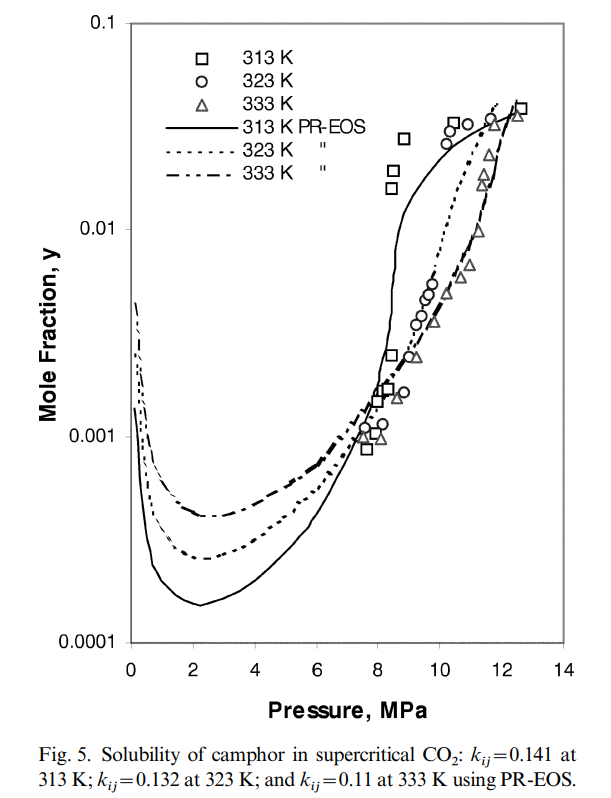

In [122]:
R = 8.3145e-6 #MJ/molK
# Constantes puras (Alcanfor = 1, CO2 = 2)
sus = ["Alcanfor", "Dioxido de Carbono"]
CAS = np.array([chemicals.search_chemical('camphor').CASs, chemicals.search_chemical('carbon dioxide').CASs])
Tc = np.array([chemicals.Tc(CAS[0]), chemicals.Tc(CAS[1])]) # K
Pc = np.array([chemicals.Pc(CAS[0]), chemicals.Pc(CAS[1])])/(10**6)  # MPa
omega = np.array([chemicals.omega(CAS[0]), chemicals.omega(CAS[1])])
k12, l12 = 5.4695e-2 , -0.6598e-2 #del articulo :)


def calc_eos_cst_pure(T):
    # PR
    b1 = 0.07780*(R*Tc[0]/Pc[0])
    a1 = 0.45724*((R*Tc[0])**2/Pc[0])*(1+(0.37464+1.54226*omega[0]-0.2699*omega[0]**2)*(1-(T/Tc[0])**0.5))**2
    b2 = 0.07780*(R*Tc[1]/Pc[1])
    a2 = 0.45724*((R*Tc[1])**2/Pc[1])*(1+(0.37464+1.54226*omega[1]-0.2699*omega[1]**2)*(1-(T/Tc[1])**0.5))**2
    return a1, b1, a2, b2



def calc_eos_cst_mix(x1, x2, k12, l12, amatriz, bs):
    bmix = bs[0]*x1**2 + 2*x1*x2*(((bs[0]+bs[1])/2)*(1-l12)) + bs[1]*x2**2
    amix = amatriz[0][0]*x1**2 + amatriz[1][0]*x2**2 + 2*amatriz[0][1]*x1*x2
    return amix, bmix


def PR_mix(T, P, amix, bmix, phase: Literal['liquid', 'vapor'] = 'liquid'):
    # z1 es la composicion de alcanfor en la fase que esta representando la ecuacion de Peng Robinson.
    # OBJ: Calcular el volumen de la fase
    # P = MPa

    opciones_validas = ['liquid', 'vapor']
    if phase not in opciones_validas:
        raise ValueError(f"phase '{phase}' no es válido. Debe ser uno de: {opciones_validas}")

    A = (amix * P) / ((R * T) ** 2)
    B = (bmix * P) / (R * T)
    
    c3 = 1.0
    c2 = -(1.0 - B)
    c1 = A - 2.0 * B - 3.0 * B**2 
    c0 = -(A * B - B**2 - B**3)
    
    raices = np.roots([c3, c2, c1, c0])
    raices_reales = raices[np.isclose(raices.imag, 0.0, atol=1e-9)].real
    raices_validas = [r for r in raices_reales if r > B]

    if len(raices_validas) == 0:
        raise RuntimeError("No se encontraron raíces reales físicamente válidas (Z > B) para el factor de compresibilidad Z.")

    if phase == "liquid":
        Z = min(raices_validas)
    else:  
        Z = max(raices_validas)

    v = (Z * R * T) / P

    return v

In [123]:
#OBJ: Calcular cuanto CO2 es necesario en gramos. 
#Escogimos una P = 8.5 MPa y una T inicial de 313 K.
#Entonces, tenemos un volumen fijo tambien, la idea es determinar la fraccion de sCO2 necesaria. Y conocemos la de alcanfor que es de 

V = 20e-6 #m^3

#Proceso: Obtener volumen especifico de la mezcla, luego dividir volumen total sobre volumen en 
# especifico, y asi obtenemos el numero de moles totales. Luego eso lo multiplicamos por las fracciones, 
# y luego a cada fraccion por su masa molar, y asi obtenemos las masas requeridas de cada sustancia para estar en 
# una fase homogenea en eas condiciones. Y en base a la grafica, sabemos que al aumentar la temepratura, se formaran dos fases. 
#Usaremos losparametros de interaccion binaria del articulo del cual la grafica es permaneciente a 

kij_313K = 0.132
lij_313K = 0

z1 = 3e-3 #Estimado con gemini, aqui entre nos
z2 = 1- z1

z = [z1, z2]


a1, b1, a2, b2 = calc_eos_cst_pure(T)
a12 = np.sqrt(a1 * a2) * (1.0 - k12)
a_matriz = [[a1, a12],[a12,a2]]
bs = [b1, b2]

amixV, bmixV = calc_eos_cst_mix(z[0], z[1], kij_313K, lij_313K, a_matriz, bs)

# def PR_mix(T, P, amix, bmix, phase : Literal['liquid', 'vapor'] = 'liquid'):

v = PR_mix(313, 8.5, amixV, bmixV, phase = 'vapor') #m^3/mol


moles = V/v

mW = [chemicals.search_chemical('camphor').MW, chemicals.search_chemical('carbon dioxide').MW]

m=[moles*z[0]*mW[0], moles*z[1]*mW[1]]

print(f"Mass of camphor: {m[0]} g \nMass of CO2: {m[1]} g")


Mass of camphor: 0.3069154197080241 g 
Mass of CO2: 29.486891056151144 g


In [ ]:
from scipy.optimize import minimize 

def PR_mixP(T, v, amix, bmix):
    #P = MPa
    return R*T/(v-bmix) - amix/(v**2 + 2*bmix*v - bmix**2)



def error(T):    
    a1, b1, a2, b2 = calc_eos_cst_pure(T)
    a12 = np.sqrt(a1 * a2) * (1.0 - k12)
    a_matriz = [[a1, a12],[a12,a2]]
    bs = [b1, b2]
    amixV333, bmixV333 = calc_eos_cst_mix(z[0], z[1], 0.132, 0, a_matriz, bs)    
    return abs(8.963184 - PR_mixP(T, v, amixV333, bmixV333))


sol = minimize(error, 313, bounds=[(313, 333.15)])
Tsol = sol.x[0]
print(f"Tsol: {Tsol} K")

a1, b1, a2, b2 = calc_eos_cst_pure(Tsol)
a12 = np.sqrt(a1 * a2) * (1.0 - k12)
a_matriz = [[a1, a12],[a12,a2]]
bs = [b1, b2]
amixVT, bmixVT = calc_eos_cst_mix(z[0], z[1], 0.132, 0, a_matriz, bs)


print(f"P0 = {PR_mixP(313, v, amixV, bmixV)} MPa \nPf = {PR_mixP(Tsol, v, amixVT, bmixVT)} MPa")


Tsol: 320.46475119868563 K
P0 = 8.500000000003297 MPa 
Pf = 8.963183994640872 MPa


In [132]:
import numpy as np
from scipy.optimize import root_scalar
import chemicals

class CamphorCO2_VLE:
    def __init__(self, z, k12, l12):
        self.R = 8.314462618e-6  # MPa m3 / mol K
        self.z = np.array(z)     # Composición global [z_camphor, z_CO2]
        self.k12 = k12
        self.l12 = l12
        
        # Propiedades puras
        cas_camphor = chemicals.search_chemical('camphor').CASs
        cas_co2 = chemicals.search_chemical('carbon dioxide').CASs
        
        self.Tc = np.array([chemicals.Tc(cas_camphor), chemicals.Tc(cas_co2)])
        self.Pc = np.array([chemicals.Pc(cas_camphor)/1e6, chemicals.Pc(cas_co2)/1e6])
        self.omega = np.array([chemicals.omega(cas_camphor), chemicals.omega(cas_co2)])

    def wilson_K(self, T, P):
        lnKi = np.log(self.Pc / P) + 5.373 * (1 + self.omega) * (1 - self.Tc / T)
        return np.exp(lnKi)

    def calc_eos_cst_pure(self, T):
        b = 0.07780 * (self.R * self.Tc / self.Pc)
        kappa = 0.37464 + 1.54226 * self.omega - 0.2699 * self.omega**2
        alpha = (1 + kappa * (1 - np.sqrt(T / self.Tc)))**2
        a = 0.45724 * ((self.R * self.Tc)**2 / self.Pc) * alpha
        return a, b

    def calc_eos_cst_mix(self, y, a, b):
        a_matrix = np.array([
            [a[0], np.sqrt(a[0]*a[1])*(1-self.k12)],
            [np.sqrt(a[0]*a[1])*(1-self.k12), a[1]]
        ])
        bmix = b[0]*y[0]**2 + 2*y[0]*y[1]*(((b[0]+b[1])/2)*(1-self.l12)) + b[1]*y[1]**2
        amix = a_matrix[0,0]*y[0]**2 + a_matrix[1,1]*y[1]**2 + 2*a_matrix[0,1]*y[0]*y[1]
        return amix, bmix, a_matrix

    def calc_fugacity_coeff(self, T, P, fractions, a, b, phase_type='vapor'):
        amix, bmix, a_matrix = self.calc_eos_cst_mix(fractions, a, b)
        A = amix * P / (self.R**2 * T**2)
        B = bmix * P / (self.R * T)

        # Polinomio corregido
        coeff = [1.0, -(1.0 - B), A - 2.0 * B - 3.0 * B**2, -(A * B - B**2 - B**3)]
        roots = np.roots(coeff)
        roots_real = roots[np.isclose(roots.imag, 0.0, atol=1e-9)].real
        
        valid_roots = [r for r in roots_real if r > B]
        if not valid_roots:
            return None
            
        Z = min(valid_roots) if phase_type == 'liquid' else max(valid_roots)
        sqrt2 = np.sqrt(2.0)
        arg_log = (Z + (1.0 + sqrt2) * B) / (Z + (1.0 - sqrt2) * B)
        suma_aj = np.dot(a_matrix, fractions)
        
        term1 = (b / bmix) * (Z - 1.0)
        term2 = -np.log(Z - B)
        term3 = -A / (2.0 * sqrt2 * B)
        term4 = (2.0 * suma_aj / amix) - (b / bmix)
        term5 = np.log(arg_log)

        return np.exp(term1 + term2 + term3 * term4 * term5)

    # =========================================================================
    # NUEVOS ALGORITMOS: Búsqueda de Temperatura de Equilibrio sin asumir 'v'
    # =========================================================================

    def find_dew_T(self, P, T_guess_min=300, T_guess_max=360):
        """Encuentra la temperatura donde aparece la primera gota de líquido (y = z)"""
        def dew_objective(T):
            y = self.z # En el punto de rocío, el vapor tiene la composición global
            K = self.wilson_K(T, P)
            a, b = self.calc_eos_cst_pure(T)
            
            # Iteración interna para estabilizar los valores K a esta Temperatura
            for _ in range(50):
                x = y / K
                sum_x = np.sum(x)
                x_norm = x / sum_x
                
                phiL = self.calc_fugacity_coeff(T, P, x_norm, a, b, 'liquid')
                phiV = self.calc_fugacity_coeff(T, P, y, a, b, 'vapor')
                
                if phiL is None or phiV is None: return 1.0 # Penalización si no hay raíces físicas
                
                K_new = phiL / phiV
                if np.sum(np.abs(K_new - K)) < 1e-5: break
                K = K_new
                
            # Objetivo: La suma de las fracciones del líquido debe ser 1.0
            return np.sum(y / K) - 1.0

        # Brentq es extremadamente rápido y estable para encontrar la raíz
        try:
            sol = root_scalar(dew_objective, bracket=[T_guess_min, T_guess_max], method='brentq')
            return sol.root
        except ValueError:
            return None # No hay punto de rocío en este rango

    def find_bubble_T(self, P, T_guess_min=300, T_guess_max=360):
        """Encuentra la temperatura donde aparece la primera burbuja de vapor (x = z)"""
        def bubble_objective(T):
            x = self.z # En el punto de burbuja, el líquido tiene la composición global
            K = self.wilson_K(T, P)
            a, b = self.calc_eos_cst_pure(T)
            
            for _ in range(50):
                y = K * x
                sum_y = np.sum(y)
                y_norm = y / sum_y
                
                phiL = self.calc_fugacity_coeff(T, P, x, a, b, 'liquid')
                phiV = self.calc_fugacity_coeff(T, P, y_norm, a, b, 'vapor')
                
                if phiL is None or phiV is None: return 1.0
                
                K_new = phiL / phiV
                if np.sum(np.abs(K_new - K)) < 1e-5: break
                K = K_new
                
            # Objetivo: La suma de las fracciones de vapor debe ser 1.0
            return np.sum(K * x) - 1.0

        try:
            sol = root_scalar(bubble_objective, bracket=[T_guess_min, T_guess_max], method='brentq')
            return sol.root
        except ValueError:
            return None


# --- Ejecución Principal ---
# Parámetros (usando z_camphor = 0.15 para asegurar que caemos dentro de la envolvente bifásica)
z_feed = [0.15, 0.85] 
k12, l12 = 0.132, 0.0 # Parámetros ajustados de tu código anterior
P_target = 8.963184 # MPa

print(f"Buscando temperaturas de equilibrio térmico a P = {P_target:.4f} MPa...\n")

vle_model = CamphorCO2_VLE(z_feed, k12, l12)

# 1. Encontrar Temperatura de Rocío (Dew Point)
T_dew = vle_model.find_dew_T(P_target, 310, 350)
if T_dew:
    print(f"Temperatura de Rocío (Dew Point T):    {T_dew:.3f} K")
else:
    print("No se encontró punto de rocío en este rango.")
T_bub = vle_model.find_bubble_T(P_target, T_guess_min=318, T_guess_max=330)

if T_bub:
    print(f"Temperatura de Burbuja (x = 0.15): {T_bub:.3f} K")
else:
    print("No se encontró punto de burbuja.")

# 2. Encontrar Temperatura de Rocío para una composición REALISTA
# El vapor no soporta z = 0.15. Probemos con z = 0.003 (0.3%), que sí cae en la línea punteada
vle_model.z = np.array([0.003, 0.997]) 
T_dew = vle_model.find_dew_T(P_target, T_guess_min=318, T_guess_max=330)

if T_dew:
    print(f"Temperatura de Rocío (y = 0.003): {T_dew:.3f} K")

Buscando temperaturas de equilibrio térmico a P = 8.9632 MPa...

No se encontró punto de rocío en este rango.
No se encontró punto de burbuja.
Temperatura de Rocío (y = 0.003): 318.742 K
